## 1. ANALYZE DATA FROM THE FIRST USER STUDY

In [ ]:
import bisect
import collections
import csv
import datetime as dt
import json
import pathlib
import random
import statistics as st

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Inline, NOT Agg. Agg is a file-writing backend that renders nothing in a
# notebook -- figures would silently come out blank.
%matplotlib inline

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

LABELS_PATH = pathlib.Path("../data/user_loa_labels.csv")
RAW_PATH_ALL = pathlib.Path("../data/raw_data.jsonl")
CAL_DIR_ALL = pathlib.Path("../data/calibration_data")


### 1.1. Label evolution over the session

In [2]:
# colors
SERIES = [
    ("#2a78d6", "o", (0, ())),                 # blue    -- solid
    ("#eb6834", "s", (0, (6, 2))),             # orange  -- dashed
    ("#1baf7a", "^", (0, (1, 1.6))),           # aqua    -- dotted
    ("#eda100", "D", (0, (7, 2, 1.5, 2))),     # yellow  -- dash-dot
    ("#e87ba4", "v", (0, (3, 1.6))),           # magenta -- short dash
]
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
INK_MUTED = "#8f8e88"
GRID = "#e6e5e1"

# LoA -> action, from decision_engine._LOA_POLICY. .
LOA_ACTIONS = {0: "none", 1: "suggest", 2: "ask approval", 3: "auto w/ veto", 4: "auto"}

In [3]:
def parse_iso(ts: str):
    try:
        return dt.datetime.fromisoformat(str(ts).strip())
    except Exception:
        return None


def load(path: pathlib.Path):
    """rows -> [(pid, session, window_idx, function, marks[])], sorted."""
    out = []
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        for r in csv.DictReader(f):
            sid = (r.get("session_id") or "").strip()
            fn = (r.get("functionname") or "").strip()
            raw = (r.get("user_selected_loa") or "").strip()
            if not sid or not fn or not raw:
                continue
            try:
                w = int(float(r.get("window_idx") or ""))
            except ValueError:
                continue
            marks = []
            for part in raw.replace(",", ";").split(";"):
                part = part.strip()
                if not part:
                    continue
                try:
                    v = int(float(part))
                except ValueError:
                    print(f"[warn] un-parseable LoA {part!r} in {raw!r} -- ignored")
                    continue
                if not 0 <= v <= 4:
                    print(f"[warn] LoA {v} outside 0..4 in {raw!r} -- clamped")
                marks.append(max(0, min(4, v)))
            if not marks:
                continue
            out.append({
                "pid": (r.get("participantid") or "unknown").strip() or "unknown",
                "session": sid,
                "window": w,
                "function": fn,
                "marks": sorted(set(marks)),
                "start": parse_iso(r.get("window_start_timestamp") or ""),
            })
    return out


def panel(ax, rows, functions, colours, max_window):
    """One session: window_idx on x, marked LoA on y, one line per function."""
    for fn in functions:
        pts = sorted((r["window"], r["marks"]) for r in rows if r["function"] == fn)
        if not pts:
            continue
        colour, marker, dashes = colours[fn]
        xs = [w for w, _ in pts]
        ys = [sum(m) / len(m) for _, m in pts]
        # multi-mark range bars first, so the line and marker sit on top
        for w, m in pts:
            if len(m) > 1:
                ax.plot([w, w], [min(m), max(m)], color=colour, lw=4,
                        alpha=0.28, solid_capstyle="round", zorder=2)
        ax.plot(xs, ys, color=colour, lw=2, linestyle=dashes, marker=marker,
                markersize=7, markerfacecolor=colour, markeredgecolor=SURFACE,
                markeredgewidth=1.4, zorder=3, clip_on=False)

    ax.set_ylim(-0.35, 4.35)
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"{k} · {LOA_ACTIONS[k]}" for k in range(5)],
                       fontsize=9, color=INK_2)
    ax.set_xlim(0.4, max_window + 0.6)
    step = 1 if max_window <= 20 else (2 if max_window <= 40 else 5)
    ax.set_xticks([w for w in range(1, max_window + 1) if w % step == 0 or w == 1])
    ax.tick_params(axis="x", labelsize=9, colors=INK_2, length=0)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor(SURFACE)

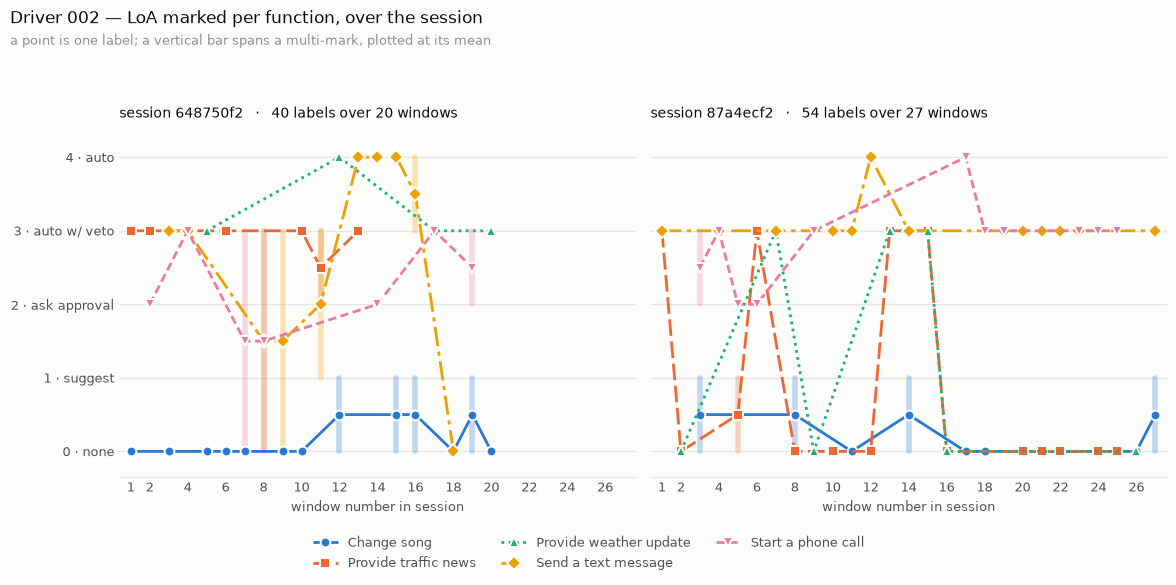

[p002] 2 session(s), 94 labels


,participantid,session_id,session_order,window_idx,functionname,marked_loa,n_marks,mean_loa
0,002,648750f2-e426-43bc-96c7-09a105a73a10,1,1,Change song,0,1,0.0
1,002,648750f2-e426-43bc-96c7-09a105a73a10,1,1,Provide traffic news,3,1,3.0
2,002,648750f2-e426-43bc-96c7-09a105a73a10,1,2,Provide traffic news,3,1,3.0
3,002,648750f2-e426-43bc-96c7-09a105a73a10,1,2,Start a phone call,2,1,2.0
4,002,648750f2-e426-43bc-96c7-09a105a73a10,1,3,Change song,0,1,0.0
...,...,...,...,...,...,...,...,...
89,002,87a4ecf2-d0c4-4ab8-8fce-a519f31d01de,2,25,Start a phone call,3,1,3.0
90,002,87a4ecf2-d0c4-4ab8-8fce-a519f31d01de,2,26,Change song,0,1,0.0
91,002,87a4ecf2-d0c4-4ab8-8fce-a519f31d01de,2,26,Provide weather update,0,1,0.0
92,002,87a4ecf2-d0c4-4ab8-8fce-a519f31d01de,2,27,Change song,0;1,2,0.5


In [4]:
PARTICIPANT_ID = "002"

path = pathlib.Path("../data/user_loa_labels.csv")
if not path.exists():
    raise FileNotFoundError(f"labels not found: {path}")
rows = load(path)
if not rows:
    raise ValueError("no usable label rows")

# Colour is assigned from the functions present in the WHOLE file, BEFORE the
# participant filter, so a function keeps the same colour across participants
# even when one of them never saw it. Assigning from the filtered rows instead
# would silently recolour the figure per driver and make two drivers' plots
# impossible to compare. Fixed order, never cycled -- past the validated slots
# there is no approved hue, and inventing one makes two functions look alike.
functions = sorted({r["function"] for r in rows})
if len(functions) > len(SERIES):
    raise ValueError(
        f"{len(functions)} distinct functions but only {len(SERIES)} validated "
        f"palette slots. Extend SERIES with the next slot(s) of the categorical "
        f"theme and RE-RUN the palette validator before trusting the figure.\n"
        f"  functions: {functions}")
colours = {fn: SERIES[i] for i, fn in enumerate(functions)}

prs = [r for r in rows if r["pid"] == PARTICIPANT_ID]
if not prs:
    raise ValueError(f"no labels for participant {PARTICIPANT_ID!r}. "
                     f"Available: {sorted({r['pid'] for r in rows})}")

# Sessions in CHRONOLOGICAL order (earliest window), not by id string --
# a session id is a uuid and sorts arbitrarily.
starts = {}
for r in prs:
    s = r["session"]
    if r["start"] is not None and (s not in starts or r["start"] < starts[s]):
        starts[s] = r["start"]
sessions = sorted({r["session"] for r in prs},
                  key=lambda s: (starts.get(s) or dt.datetime.max, s))

ncols = min(len(sessions), 2)
nrows = (len(sessions) + ncols - 1) // ncols
max_window = max(r["window"] for r in prs)
# ~0.19 in per window keeps a panel near 3:2. Wider than that flattens the
# vertical axis until a 4 -> 0 step reads as a gentle slope, which is the
# one thing this figure exists to show.
panel_w = max(4.5, min(0.19 * max_window, 7.5))
fig, axes = plt.subplots(
    nrows, ncols, squeeze=False, sharey=True,
    figsize=(1.6 + panel_w * ncols, 4.1 * nrows + 1.7))
fig.patch.set_facecolor(SURFACE)

for k, sid in enumerate(sessions):
    ax = axes[k // ncols][k % ncols]
    srows = [r for r in prs if r["session"] == sid]
    panel(ax, srows, functions, colours, max_window)
    nw = len({r["window"] for r in srows})
    ax.set_title(f"session {sid[:8]}   ·   {len(srows)} labels over {nw} windows",
                 fontsize=10, color=INK, pad=10, loc="left")
    ax.set_xlabel("window number in session", fontsize=9, color=INK_2)
for k in range(len(sessions), nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")

# Every function keeps a legend entry, including any this driver was never asked
# about -- so the legend reads identically across drivers and an absent line is
# visibly an absent line rather than a missing function.
handles = [Line2D([], [], color=colours[fn][0], marker=colours[fn][1],
                  linestyle=colours[fn][2], lw=2, markersize=7,
                  markeredgecolor=SURFACE, markeredgewidth=1.4, label=fn)
           for fn in functions]
fig.legend(handles=handles, loc="lower center", ncol=min(len(functions), 3),
           frameon=False, fontsize=9, labelcolor=INK_2,
           bbox_to_anchor=(0.5, 0.0))
fig.suptitle(f"Driver {PARTICIPANT_ID} — LoA marked per function, over the session",
             fontsize=12.5, color=INK, x=0.012, ha="left", y=0.985)
fig.text(0.012, 0.925,
         "a point is one label; a vertical bar spans a multi-mark, plotted at its mean",
         fontsize=9, color=INK_MUTED, ha="left")
fig.tight_layout(rect=(0, 0.09, 1, 0.90))

# Display inline; nothing is written to disk. plt.show() also releases the
# figure, so no plt.close() and no duplicate render from the inline backend.
plt.show()

order_of = {sid: i for i, sid in enumerate(sessions, 1)}
table = pd.DataFrame([{
    "participantid": PARTICIPANT_ID,
    "session_id": r["session"],
    "session_order": order_of[r["session"]],
    "window_idx": r["window"],
    "functionname": r["function"],
    "marked_loa": ";".join(map(str, r["marks"])),
    "n_marks": len(r["marks"]),
    "mean_loa": round(sum(r["marks"]) / len(r["marks"]), 3),
} for r in prs]).sort_values(["session_order", "window_idx", "functionname"],
                            ignore_index=True)

never = [fn for fn in functions if fn not in {r["function"] for r in prs}]
print(f"[p{PARTICIPANT_ID}] {len(sessions)} session(s), {len(prs)} labels")
if never:
    print(f"          never asked about: {never}")

# The table is not decoration: three of the five line colours sit below 3:1
# contrast on a light surface, and the palette rule for that case requires a
# table view as relief. It is also the data behind the figure.
display(table)


### 1.2. Driver-state signals over the session

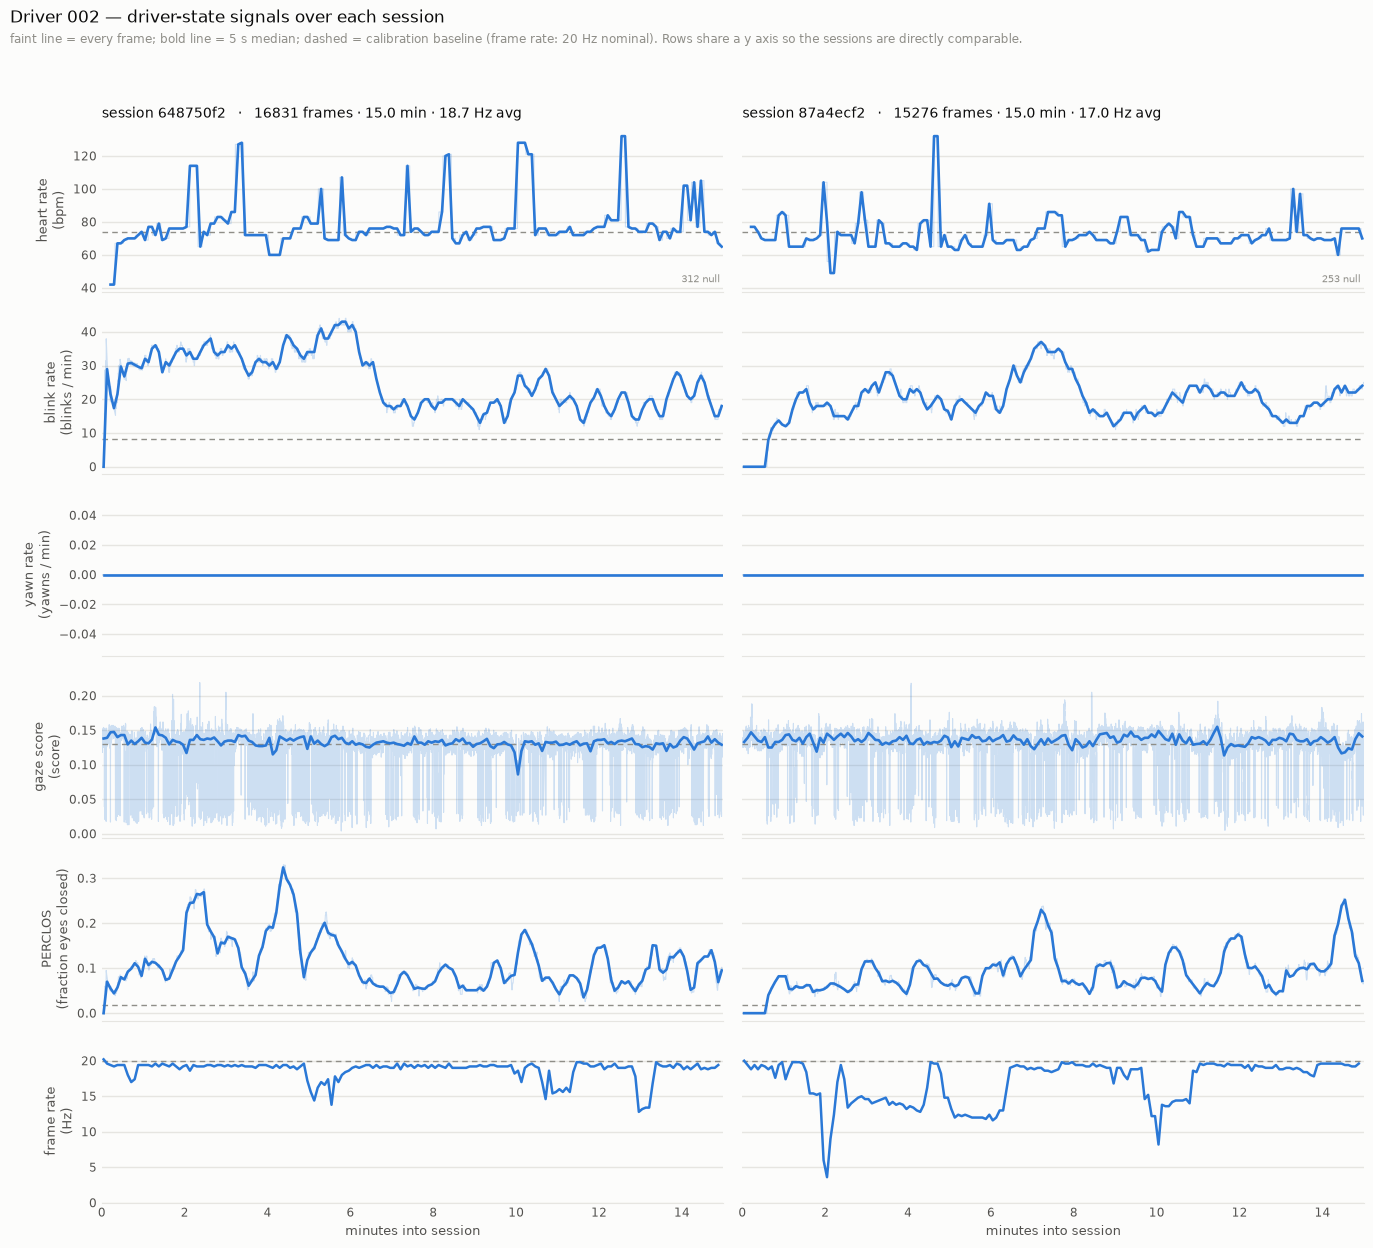

,session,signal,unit,n,n_null,min,median,max,1st half med,2nd half med
0,648750f2,heart rate,bpm,16831,312,42.000,74.000,132.000,74.000,76.000
1,648750f2,blink rate,blinks / min,16831,0,0.000,24.000,44.000,32.000,19.000
2,648750f2,yawn rate,yawns / min,16831,0,0.000,0.000,0.000,0.000,0.000
3,648750f2,gaze score,score,16831,0,0.004,0.133,0.219,0.134,0.131
4,648750f2,PERCLOS,fraction eyes closed,16831,0,0.000,0.097,0.330,0.115,0.081
5,648750f2,frame rate,Hz,179,0,12.800,19.200,20.200,19.200,19.200
6,87a4ecf2,heart rate,bpm,15276,253,49.000,70.000,132.000,69.000,70.000
7,87a4ecf2,blink rate,blinks / min,15276,0,0.000,20.000,37.000,20.000,19.000
8,87a4ecf2,yawn rate,yawns / min,15276,0,0.000,0.000,0.000,0.000,0.000
9,87a4ecf2,gaze score,score,15276,0,0.005,0.136,0.218,0.136,0.135


In [5]:
PARTICIPANT_ID = "002"

import json
import numpy as np

RAW_PATH = pathlib.Path("../data/raw_data.jsonl")
CAL_DIR = pathlib.Path("../data/calibration_data")
BIN_S = 5.0            # trend line = median per 5 s bin
NOMINAL_HZ = 20.0      # DataCollector's target rate

# RAW columns, not the normalised ones. The z-scored variants (`perclos`,
# `blink_rate`, `gaze_score`) divide by a per-driver calibration std, so their
# scale is not comparable between drivers -- and PERCLOS in particular is
# currently inflated ~14x because the PERCLOS_MIN_SCALE floor is commented out
# in data_collector.calibrate_step. Raw units are interpretable and stable; the
# dashed line is this driver's calibration baseline, which is what the
# normalised version is measured against anyway.
#   (column, label, unit, calibration key)
SIGNALS = [
    ("heart_rate",     "heart rate",   "bpm",              "bpm"),
    ("blink_rate_raw", "blink rate",   "blinks / min",     "blink_rate"),
    ("yawn_rate_raw",  "yawn rate",    "yawns / min",      None),
    ("gaze_score_raw", "gaze score",   "score",            "gaze_score"),
    ("perclos_raw",    "PERCLOS",      "fraction eyes closed", "perclos"),
    (None,             "frame rate",   "Hz",               None),   # derived below
]


def secs_of_day(ts):
    """'HH:MM:SS.fff' -> seconds since midnight."""
    try:
        h, m, s = str(ts).split(":")
        return int(h) * 3600 + int(m) * 60 + float(s)
    except Exception:
        return None


# ---- load just this participant's frames -----------------------------------
if not RAW_PATH.exists():
    raise FileNotFoundError(f"raw frames not found: {RAW_PATH}")
by_session = collections.defaultdict(list)
for line in RAW_PATH.open("r", encoding="utf-8"):
    line = line.strip()
    if not line:
        continue
    try:
        fr = json.loads(line)
    except Exception as e:
        print(f"[warn] unparseable JSON line -- frame DROPPED ({e})")
        continue
    if (fr.get("participantid") or "").strip() != PARTICIPANT_ID:
        continue
    t = secs_of_day(fr.get("timestamp"))
    if t is None:
        continue
    by_session[fr["session_id"]].append((t, fr))
if not by_session:
    raise ValueError(f"no frames for participant {PARTICIPANT_ID!r} in {RAW_PATH}")

for sid in by_session:
    by_session[sid].sort(key=lambda x: x[0])
sessions = sorted(by_session, key=lambda s: by_session[s][0][0])   # chronological

cal_path = CAL_DIR / f"calibration_{PARTICIPANT_ID}.json"
cal = json.load(cal_path.open(encoding="utf-8")) if cal_path.exists() else {}
if not cal:
    print(f"[note] no {cal_path.name} -- baseline reference lines omitted")


def binned_median(t, y, bin_s):
    """Median of y per bin_s-second bin. Robust to the NaNs in heart_rate."""
    if len(t) == 0:
        return np.array([]), np.array([])
    idx = np.floor((t - t[0]) / bin_s).astype(int)
    xs, ys = [], []
    for b in range(idx.max() + 1):
        sel = y[idx == b]
        sel = sel[~np.isnan(sel)]
        if sel.size:
            xs.append(t[0] + (b + 0.5) * bin_s)
            ys.append(float(np.median(sel)))
    return np.asarray(xs), np.asarray(ys)


LINE = SERIES[0][0]        # one series per panel, so identity comes from the title
nrows, ncols = len(SIGNALS), len(sessions)
fig, axes = plt.subplots(nrows, ncols, squeeze=False, sharex="col", sharey="row",
                         figsize=(1.4 + 6.2 * ncols, 1.85 * nrows + 1.4))
fig.patch.set_facecolor(SURFACE)

for col, sid in enumerate(sessions):
    frames = by_session[sid]
    t0 = frames[0][0]
    t_min = np.array([(t - t0) / 60.0 for t, _ in frames])       # elapsed MINUTES
    dur = t_min[-1]

    for row, (col_name, label, unit, cal_key) in enumerate(SIGNALS):
        ax = axes[row][col]

        if col_name is None:
            # Frame rate: count frames per bin. Derived from timestamps rather
            # than the logged fps_* fields, which are absent on the odd row.
            edges = np.arange(0, dur + BIN_S / 60.0, BIN_S / 60.0)
            counts, _ = np.histogram(t_min, bins=edges)
            xs = (edges[:-1] + edges[1:]) / 2
            ys = counts / BIN_S
            ax.plot(xs[:-1], ys[:-1], color=LINE, lw=1.8, zorder=3)  # drop partial last bin
            ax.axhline(NOMINAL_HZ, color=INK_MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
            ax.set_ylim(0, max(NOMINAL_HZ * 1.15, float(ys[:-1].max()) * 1.1 if ys.size > 1 else 1))
        else:
            y = np.array([float(f.get(col_name)) if isinstance(f.get(col_name), (int, float))
                          and not isinstance(f.get(col_name), bool) else np.nan
                          for _, f in frames])
            # np.nan breaks the line at gaps instead of bridging them -- a null
            # heart rate means "no reading", not "unchanged since last time".
            ax.plot(t_min, y, color=LINE, lw=0.8, alpha=0.22, zorder=2)
            bx, bfy = binned_median(t_min, y, BIN_S / 60.0)
            ax.plot(bx, bfy, color=LINE, lw=1.9, zorder=3)
            base = (cal.get(cal_key) or {}).get("mean") if cal_key else None
            if base is not None:
                ax.axhline(base, color=INK_MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
            n_ok = int(np.count_nonzero(~np.isnan(y)))
            if n_ok < len(y):
                ax.text(0.995, 0.06, f"{len(y)-n_ok} null", transform=ax.transAxes,
                        ha="right", fontsize=7.5, color=INK_MUTED)

        ax.set_xlim(0, dur)
        ax.grid(axis="y", color=GRID, lw=1, zorder=0)
        ax.set_axisbelow(True)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(GRID)
        ax.set_facecolor(SURFACE)
        ax.tick_params(labelsize=8.5, colors=INK_2, length=0)
        if col == 0:
            ax.set_ylabel(f"{label}\n({unit})", fontsize=9, color=INK_2)
        if row == 0:
            n = len(frames)
            ax.set_title(f"session {sid[:8]}   ·   {n} frames · "
                         f"{dur:.1f} min · {n/(dur*60):.1f} Hz avg",
                         fontsize=10, color=INK, pad=8, loc="left")
        if row == nrows - 1:
            ax.set_xlabel("minutes into session", fontsize=9, color=INK_2)

fig.suptitle(f"Driver {PARTICIPANT_ID} — driver-state signals over each session",
             fontsize=12.5, color=INK, x=0.008, ha="left", y=0.995)
fig.text(0.008, 0.968,
         f"faint line = every frame; bold line = {BIN_S:.0f} s median; "
         f"dashed = calibration baseline (frame rate: {NOMINAL_HZ:.0f} Hz nominal). "
         f"Rows share a y axis so the sessions are directly comparable.",
         fontsize=8.5, color=INK_MUTED, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

# Table view: per-session summary of each signal (relief for the low-contrast
# hues, and the numbers behind the trend lines).
summary = []
for sid in sessions:
    frames = by_session[sid]
    t0 = frames[0][0]
    t_min = np.array([(t - t0) / 60.0 for t, _ in frames])
    for col_name, label, unit, _k in SIGNALS:
        if col_name is None:
            edges = np.arange(0, t_min[-1] + BIN_S / 60.0, BIN_S / 60.0)
            counts, _ = np.histogram(t_min, bins=edges)
            y = (counts / BIN_S)[:-1]
        else:
            y = np.array([float(f.get(col_name)) if isinstance(f.get(col_name), (int, float))
                          and not isinstance(f.get(col_name), bool) else np.nan
                          for _, f in frames])
        ok = y[~np.isnan(y)]
        half = len(ok) // 2
        summary.append({
            "session": sid[:8], "signal": label, "unit": unit,
            "n": len(y), "n_null": int(np.isnan(y).sum()),
            "min": round(float(ok.min()), 3) if ok.size else None,
            "median": round(float(np.median(ok)), 3) if ok.size else None,
            "max": round(float(ok.max()), 3) if ok.size else None,
            "1st half med": round(float(np.median(ok[:half])), 3) if half else None,
            "2nd half med": round(float(np.median(ok[half:])), 3) if half else None,
        })
display(pd.DataFrame(summary))


### 1.3. Segment dataset — join raw frames to label windows

Everything from here on is **cross-driver** and ignores `PARTICIPANT_ID`: the questions are comparative.

One *segment* = one label = one (window, prompt) pair. The join is the same one `scripts/build_loa_dataset.py` performs — `session_id` plus the frame timestamp falling inside `[window_start, window_end]` — reproduced here so the notebook is self-contained.

In [ ]:
# Driver-state channels aggregated per segment. RAW log keys -- note 'eye_ar',
# which is what the collector writes for the model feature called 'ear'.
STATE_COLS = ['perclos', 'gaze_score', 'hr_delta', 'rr_delta', 'blink_rate', 'yawn_rate',
              'eye_ar', 'mar', 'speed_ratio_max', 'brake', 'steer', 'throttle',
              'is_junction', 'lead_distance_m']
# Kept per frame for the rPPG section (1.7) and the frame-rate figures.
KEEP_EXTRA = ['heart_rate', 'heart_rate_raw', 'respiratory_rate', 'hr_rejected',
              'perclos_raw', 'rppg_harmonic_rejects', 'face_present']


def _secs_of_day(ts):
    """'HH:MM:SS.fff' (frames) or full ISO (label windows) -> seconds since midnight."""
    if not ts:
        return None
    s = str(ts).strip()
    try:
        d = dt.datetime.fromisoformat(s)
        return d.hour * 3600 + d.minute * 60 + d.second + d.microsecond / 1e6
    except Exception:
        pass
    try:
        h, m, sec = s.split(":")
        return int(h) * 3600 + int(m) * 60 + float(sec)
    except Exception:
        return None


def _num(v):
    """Frame value -> float, with bools as 0/1 and anything unusable as NaN."""
    if isinstance(v, bool):
        return 1.0 if v else 0.0
    if v is None:
        return np.nan
    try:
        f = float(v)
        return f if f == f else np.nan
    except Exception:
        return np.nan


# ---- 1. raw frames, ALL participants, keeping only the columns we need ------
frames_by_session = collections.defaultdict(list)
n_lines = n_bad = 0
for line in RAW_PATH_ALL.open("r", encoding="utf-8"):
    line = line.strip()
    if not line:
        continue
    n_lines += 1
    try:
        fr = json.loads(line)
    except Exception:
        n_bad += 1          # a truncated tail line is the usual cause
        continue
    t = _secs_of_day(fr.get("timestamp"))
    if t is None:
        continue
    slim = {k: fr.get(k) for k in STATE_COLS + KEEP_EXTRA}
    slim["t"] = t
    frames_by_session[fr["session_id"]].append(slim)
for sid in frames_by_session:
    frames_by_session[sid].sort(key=lambda r: r["t"])
print(f"[raw] {n_lines} lines, {n_bad} unparseable, "
      f"{sum(len(v) for v in frames_by_session.values())} frames, "
      f"{len(frames_by_session)} sessions")

# ---- 2. one segment per label row ------------------------------------------
segments = []
for r in csv.DictReader(LABELS_PATH.open(encoding="utf-8-sig", newline="")):
    sid = (r.get("session_id") or "").strip()
    marks = sorted({max(0, min(4, int(float(x))))
                    for x in (r.get("user_selected_loa") or "").replace(",", ";").split(";")
                    if x.strip()})
    a, b = _secs_of_day(r.get("window_start_timestamp")), _secs_of_day(r.get("window_end_timestamp"))
    if not sid or not marks or a is None or b is None:
        continue
    fr = frames_by_session.get(sid, [])
    ts = [f["t"] for f in fr]
    lo, hi = bisect.bisect_left(ts, a), bisect.bisect_right(ts, b)
    win = fr[lo:hi]
    seg = {
        "pid": (r.get("participantid") or "unknown").strip() or "unknown",
        "session": sid,
        "window": int(float(r["window_idx"])),
        "prompt": int(float(r.get("prompt_in_window") or 0)),
        "function": (r.get("functionname") or "").strip(),
        "marks": marks,
        "y": float(np.mean(marks)),          # scalar summary of the marked SET
        "n_marks": len(marks),
        "n_frames": len(win),
        "sel_s": _secs_of_day(r.get("selection_timestamp")),
        "end_s": b,
    }
    for c in STATE_COLS:                     # mean and sd over the 20 s window
        v = np.array([_num(f.get(c)) for f in win], dtype=float)
        v = v[~np.isnan(v)]
        seg[f"{c}_mean"] = float(v.mean()) if v.size else np.nan
        seg[f"{c}_std"] = float(v.std()) if v.size else np.nan
    segments.append(seg)

# Session order is CHRONOLOGICAL (first window), not the uuid's sort order.
_first = {}
for s in segments:
    k = (s["pid"], s["session"])
    _first[k] = min(_first.get(k, 1e18), s["end_s"])
_order = {}
for pid in {p for p, _ in _first}:
    for i, (p, sid) in enumerate(sorted([k for k in _first if k[0] == pid],
                                        key=lambda k: _first[k]), 1):
        _order[(p, sid)] = i
_maxw = collections.defaultdict(int)
for s in segments:
    _maxw[(s["pid"], s["session"])] = max(_maxw[(s["pid"], s["session"])], s["window"])
for s in segments:
    s["session_order"] = _order[(s["pid"], s["session"])]
    n = _maxw[(s["pid"], s["session"])]
    s["t_norm"] = (s["window"] - 1) / (n - 1) if n > 1 else 0.0   # 0..1 through the session

seg_df = pd.DataFrame(segments)
STATE_FEATS = [c for c in seg_df.columns if c.endswith(("_mean", "_std"))]
DRIVERS = sorted(seg_df.pid.unique())
FUNCTIONS = sorted(seg_df.function.unique())
print(f"[segments] {len(seg_df)} | drivers {DRIVERS} | {len(FUNCTIONS)} functions | "
      f"{len(STATE_FEATS)} state features")
print(f"[coverage] frames per segment: min={seg_df.n_frames.min()} "
      f"med={int(seg_df.n_frames.median())} max={seg_df.n_frames.max()}"
      f" | segments with ZERO frames: {(seg_df.n_frames == 0).sum()}")
display(seg_df[["pid", "session_order", "window", "prompt", "function",
                "n_marks", "y", "n_frames"]].head())


### 1.4. Label distribution — frequency per driver and overall

A multi-mark counts toward **every** level it names, so the level counts sum to the number of *marks*, not the number of labels.

In [ ]:
def level_row(sub, name):
    """One row of the frequency table: per-level mark counts + summary stats."""
    marks = [m for s in sub for m in s]
    c = collections.Counter(marks)
    row = {"group": name, "labels": len(sub), "marks": len(marks)}
    for k in range(5):
        row[f"L{k}"] = c.get(k, 0)
    for k in range(5):
        row[f"L{k}_%"] = round(100 * c.get(k, 0) / len(marks), 1) if marks else 0.0
    row["mean"] = round(float(np.mean(marks)), 3)
    row["sd"] = round(float(np.std(marks)), 3)
    multi = [s for s in sub if len(s) > 1]
    row["multi_%"] = round(100 * len(multi) / len(sub), 1)
    row["non_contig"] = sum(1 for s in multi if (max(s) - min(s) + 1) != len(s))
    return row


rows = [level_row(seg_df.loc[seg_df.pid == p, "marks"].tolist(), f"p{p}") for p in DRIVERS]
rows.append(level_row(seg_df["marks"].tolist(), "ALL"))
freq = pd.DataFrame(rows)
print("Level frequency (a multi-mark counts toward every level it names)")
display(freq[["group", "labels", "marks"] + [f"L{k}" for k in range(5)]
             + ["mean", "sd", "multi_%", "non_contig"]])
print("Same, as a percentage of that group's marks")
display(freq[["group", "marks"] + [f"L{k}_%" for k in range(5)]])

# Per-driver x function: mean +- sd, and the between-driver gap. This is the
# table that carries the study's main structural finding.
pf = (seg_df.groupby(["pid", "function"])["y"]
      .agg(n="size", mean="mean", sd=lambda v: float(np.std(v))).round(3).reset_index())
wide = pf.pivot(index="function", columns="pid", values=["n", "mean", "sd"])
wide.columns = [f"{a}_p{b}" for a, b in wide.columns]
if len(DRIVERS) == 2:
    a, b = DRIVERS
    wide["abs_diff"] = (wide[f"mean_p{a}"] - wide[f"mean_p{b}"]).abs().round(3)
    wide["mean_sd"] = ((wide[f"sd_p{a}"] + wide[f"sd_p{b}"]) / 2).round(3)
print("Per driver x function (the scalar is the mean of the marked set)")
display(wide.sort_values("abs_diff" if "abs_diff" in wide else wide.columns[0],
                         ascending=False))

if len(DRIVERS) == 2 and wide["abs_diff"].notna().all():
    r = np.corrcoef(wide["abs_diff"], wide["mean_sd"])[0, 1]
    ra, rb = DRIVERS
    r_rank = np.corrcoef(wide[f"mean_p{ra}"], wide[f"mean_p{rb}"])[0, 1]
    print(f"corr(between-driver |difference|, within-driver sd) = {r:+.3f}")
    print(f"   negative => where drivers DISAGREE, each is individually CONSISTENT")
    print(f"corr of the two drivers' per-function means          = {r_rank:+.3f}")


### 1.5. Drift — do preferences move within a session?

A raw first-half/second-half difference confounds real drift with *which functions happened to be asked when*. The OLS regresses the marked level on function dummies **plus** normalised time-in-session, so the time slope is the drift with function composition held constant.

In [ ]:
def time_slope(sub):
    """OLS  y ~ function dummies + normalised time.  -> (slope, se, t).

    Function dummies with no intercept: they span it, so the time coefficient is
    the within-function drift rather than a mixture of drift and composition.
    """
    y = sub["y"].to_numpy(float)
    t = sub["t_norm"].to_numpy(float)
    fl = sorted(sub["function"].unique())
    D = np.zeros((len(sub), len(fl)))
    for i, f in enumerate(sub["function"]):
        D[i, fl.index(f)] = 1.0
    X = np.column_stack([D, t])
    if len(y) <= X.shape[1]:
        return np.nan, np.nan, np.nan
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    s2 = res @ res / (len(y) - X.shape[1])
    se = float(np.sqrt(np.diag(s2 * np.linalg.pinv(X.T @ X))[-1]))
    return float(beta[-1]), se, (float(beta[-1]) / se if se > 0 else np.nan)


rows = []
for (pid, order), sub in seg_df.groupby(["pid", "session_order"]):
    nw = sub["window"].max()
    h1 = sub.loc[sub.window <= nw / 2, "y"]
    h2 = sub.loc[sub.window > nw / 2, "y"]
    slope, se, tstat = time_slope(sub)
    rows.append({
        "driver": f"p{pid}", "session": order, "n": len(sub), "windows": nw,
        "1st half": round(h1.mean(), 3), "2nd half": round(h2.mean(), 3),
        "half diff": round(h2.mean() - h1.mean(), 3),
        "fn-adj slope": round(slope, 3), "se": round(se, 3), "t": round(tstat, 2),
        "significant": "YES" if abs(tstat) > 2 else "no",
    })
print("Drift per session  (slope = change in marked LoA across the whole session)")
display(pd.DataFrame(rows))

# Per driver x function x third -- where in the scale the drift actually happens.
thirds = []
for (pid, order, fn), sub in seg_df.groupby(["pid", "session_order", "function"]):
    nw = _maxw[(pid, sub["session"].iloc[0])]
    cells = {}
    for k in range(3):
        sel = sub[(sub.window > nw * k / 3) & (sub.window <= nw * (k + 1) / 3)]
        cells[f"T{k+1}"] = round(sel["y"].mean(), 2) if len(sel) else np.nan
        cells[f"n{k+1}"] = len(sel)
    vals = [v for kk, v in cells.items() if kk.startswith("T") and v == v]
    thirds.append({"driver": f"p{pid}", "session": order, "function": fn, **cells,
                   "shape": ("stable" if not vals or max(vals) - min(vals) < 0.8
                             else "DROP" if vals[-1] < vals[0] - 0.8 else "RISE")})
print("By third of the session, per driver x function")
display(pd.DataFrame(thirds).sort_values(["driver", "session", "function"], ignore_index=True))


### 1.6. Carry-over — are the two prompts of a window independent?

Both prompts share the same 20 s of driving and differ only in the function asked about. If the second answer were anchored on the first, the second prompt would carry less information than a fresh window and the paired design would be worth less than its label count suggests.

**Test:** agreement between the two answers *within* a window, against agreement between two randomly drawn answers from *different* windows of the same session. Equal or lower ⇒ no carry-over.

In [ ]:
N_PERM = 30000     # random cross-window draws per session for the baseline


def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)


rows = []
for pid in DRIVERS:
    P = seg_df[seg_df.pid == pid]
    pairs = [g for _, g in P.groupby(["session", "window"]) if len(g) == 2]
    if not pairs:
        rows.append({"driver": f"p{pid}", "pairs": 0}); continue
    within_eq = np.mean([set(g.marks.iloc[0]) == set(g.marks.iloc[1]) for g in pairs])
    within_j = np.mean([jaccard(g.marks.iloc[0], g.marks.iloc[1]) for g in pairs])
    same_fn = sum(g.function.iloc[0] == g.function.iloc[1] for g in pairs)

    rng = random.Random(0)
    eq, jc = [], []
    for sid, S in P.groupby("session"):
        recs = S.to_dict("records")
        for _ in range(N_PERM):
            x, y2 = rng.sample(recs, 2)
            if x["window"] == y2["window"]:
                continue                      # cross-WINDOW baseline only
            eq.append(set(x["marks"]) == set(y2["marks"]))
            jc.append(jaccard(x["marks"], y2["marks"]))

    gaps = sorted(abs(g.sel_s.iloc[1] - g.sel_s.iloc[0]) for g in pairs
                  if g.sel_s.notna().all())
    delib = sorted((g.sel_s.min() - g.end_s.iloc[0]) for g in pairs if g.sel_s.notna().all())
    rows.append({
        "driver": f"p{pid}", "pairs": len(pairs),
        "within agree %": round(100 * within_eq, 1),
        "cross agree %": round(100 * np.mean(eq), 1),
        "within Jaccard": round(within_j, 3),
        "cross Jaccard": round(float(np.mean(jc)), 3),
        "verdict": ("no carry-over" if within_j <= np.mean(jc) + 0.02 else "CARRY-OVER?"),
        "same function": same_fn,
        "gap med (s)": round(gaps[len(gaps) // 2], 2) if gaps else None,
        "gap <1s": f"{sum(1 for g in gaps if g < 1)}/{len(gaps)}" if gaps else None,
        "delib med (s)": round(delib[len(delib) // 2], 2) if delib else None,
    })
print("Carry-over between the two prompts of a window")
display(pd.DataFrame(rows))
print("within <= cross  =>  the second answer is NOT anchored on the first.")
print("'gap' is the time between the two confirmations; sub-second gaps would mean")
print("one submit registered both answers rather than two separate judgements.")


### 1.7. rPPG plausibility

`hr_delta` is a model input, so a bad heart rate is contamination rather than a logging nuisance.

The failure mode to look for is **harmonic**: the estimator picks the largest spectral peak in 36–198 bpm with no harmonic disambiguation, so a true rate below ~99 bpm can be reported at 2f, and one above ~72 bpm at f/2. Readings near half or double the calibration baseline are therefore suspect, not merely extreme.

In [ ]:
HR_LO, HR_HI = 50.0, 110.0      # plausible seated range
HARMONIC_TOL = 0.15             # within +-15% of f/2 or 2f counts as suspect

# session -> driver, recovered from the segment table
sess_pid = dict(zip(seg_df.session, seg_df.pid))
sess_ord = dict(zip(seg_df.session, seg_df.session_order))

rows = []
for sid, frames in frames_by_session.items():
    pid = sess_pid.get(sid)
    if pid is None:
        continue                                  # session with no labels
    cal_p = CAL_DIR_ALL / f"calibration_{pid}.json"
    base = (json.load(cal_p.open(encoding="utf-8"))["bpm"]["mean"]
            if cal_p.exists() else np.nan)
    hr = np.array([_num(f.get("heart_rate")) for f in frames])
    rr = np.array([_num(f.get("respiratory_rate")) for f in frames])
    hr_ok = hr[~np.isnan(hr)]
    rr_ok = rr[~np.isnan(rr)]
    rej = sum(1 for f in frames if f.get("hr_rejected") is True)
    if base == base and hr_ok.size:
        half = np.abs(hr_ok - base / 2) <= HARMONIC_TOL * base / 2
        dbl = np.abs(hr_ok - 2 * base) <= HARMONIC_TOL * 2 * base
    else:
        half = dbl = np.array([False])
    rows.append({
        "driver": f"p{pid}", "session": sess_ord.get(sid), "sid": sid[:8],
        "frames": len(frames), "hr_null": int(np.isnan(hr).sum()),
        "cal bpm": base,
        "hr min": hr_ok.min() if hr_ok.size else None,
        "hr med": float(np.median(hr_ok)) if hr_ok.size else None,
        "hr max": hr_ok.max() if hr_ok.size else None,
        "hr distinct": int(len(set(hr_ok.tolist()))),
        f"<{HR_LO:.0f}": int((hr_ok < HR_LO).sum()),
        f">{HR_HI:.0f}": int((hr_ok > HR_HI).sum()),
        "out %": round(100 * ((hr_ok < HR_LO) | (hr_ok > HR_HI)).sum() / max(hr_ok.size, 1), 1),
        "~f/2": int(half.sum()), "~2f": int(dbl.sum()),
        "hr_rejected": rej,
        "harm_rejects": frames[-1].get("rppg_harmonic_rejects"),
        "rr distinct": int(len(set(rr_ok.tolist()))),
        "rr med": float(np.median(rr_ok)) if rr_ok.size else None,
    })
rppg = pd.DataFrame(rows).sort_values(["driver", "session"], ignore_index=True)
print("rPPG per session")
display(rppg)
print(f"'~f/2' and '~2f' count readings within {100*HARMONIC_TOL:.0f}% of half / double the")
print("calibration baseline -- the signature of a harmonic pick, not of real tachycardia.")
print("'hr_rejected' is the live filter firing; those readings still reach heart_rate.")

# Distribution per driver, with the baseline and its harmonics marked.
fig, axes = plt.subplots(1, len(DRIVERS), squeeze=False, figsize=(5.6 * len(DRIVERS), 3.2))
fig.patch.set_facecolor(SURFACE)
for i, pid in enumerate(DRIVERS):
    ax = axes[0][i]
    sids = [s for s in frames_by_session if sess_pid.get(s) == pid]
    hr = np.concatenate([[_num(f.get("heart_rate")) for f in frames_by_session[s]] for s in sids])
    hr = hr[~np.isnan(hr)]
    ax.hist(hr, bins=np.arange(30, 200, 2), color=SERIES[0][0], zorder=3)
    cal_p = CAL_DIR_ALL / f"calibration_{pid}.json"
    if cal_p.exists():
        b = json.load(cal_p.open(encoding="utf-8"))["bpm"]["mean"]
        for x, lab in ((b, "baseline"), (b / 2, "f/2"), (2 * b, "2f")):
            ax.axvline(x, color=INK_MUTED, lw=1, ls=(0, (4, 3)), zorder=4)
            ax.text(x, ax.get_ylim()[1] * 0.94, f" {lab}", fontsize=8, color=INK_MUTED)
    ax.axvspan(HR_LO, HR_HI, color=GRID, alpha=0.55, zorder=0)
    ax.set_title(f"p{pid} — heart rate, all sessions", fontsize=10, color=INK, loc="left")
    ax.set_xlabel("bpm", fontsize=9, color=INK_2)
    ax.set_ylabel("frames", fontsize=9, color=INK_2)
    ax.tick_params(labelsize=8.5, colors=INK_2, length=0)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor(SURFACE)
fig.tight_layout()
plt.show()


### 1.8. Where is the learnable signal? — variance decomposition and set-MAE

**set-MAE** is the distance from a prediction to the *nearest* level the driver marked acceptable, which is the metric the design selects models on. It reduces to plain MAE on single-mark labels.

The four predictors are nested, and the gaps between them are what matter:
- **per-function mean** is the ceiling for a population model that never sees driver identity — the xLSTM's FCD pathway.
- **per-driver × function mean** is the ceiling for personalization.

These are *in-sample* ceilings (fitted and evaluated on the same data), so they are upper bounds, not achievable scores.

In [ ]:
def set_mae(pred, marks):
    """Distance to the NEAREST marked level -- plain MAE when one level is marked."""
    return min(abs(pred - m) for m in marks)


def score(name, predict):
    e = [set_mae(predict(r), r["marks"]) for r in segments]
    hit = [1.0 if int(round(predict(r))) in r["marks"] else 0.0 for r in segments]
    return {"predictor": name, "set-MAE": round(float(np.mean(e)), 3),
            "hit@round %": round(100 * float(np.mean(hit)), 1)}


gm = seg_df["y"].mean()
m_fn = seg_df.groupby("function")["y"].mean().to_dict()
m_pid = seg_df.groupby("pid")["y"].mean().to_dict()
m_pf = seg_df.groupby(["pid", "function"])["y"].mean().to_dict()

baselines = pd.DataFrame([
    score("constant (global mean)", lambda r: gm),
    score("per-DRIVER mean", lambda r: m_pid[r["pid"]]),
    score("per-FUNCTION mean   <- population-model ceiling", lambda r: m_fn[r["function"]]),
    score("per-DRIVER x FUNCTION   <- personalization ceiling",
          lambda r: m_pf[(r["pid"], r["function"])]),
])
print("In-sample ceilings")
display(baselines)
pop, per = baselines.loc[2, "set-MAE"], baselines.loc[3, "set-MAE"]
print(f"personalization vs the population ceiling: set-MAE {pop:.3f} -> {per:.3f}, "
      f"an error REDUCTION of {pop-per:.3f} ({100*(pop-per)/pop:.1f}%); "
      f"hit rate {baselines.loc[2,'hit@round %']:.1f}% -> {baselines.loc[3,'hit@round %']:.1f}%")

# ---- variance decomposition -------------------------------------------------
y = seg_df["y"].to_numpy(float)
tot = y.var()


def explained(keys):
    """Fraction of variance removed by conditioning on `keys` (grouped means)."""
    within = (seg_df.groupby(keys)["y"]
              .transform(lambda v: (v - v.mean()) ** 2).sum() / len(seg_df))
    return 1 - within / tot


rows = [
    ("function alone", explained(["function"])),
    ("driver alone", explained(["pid"])),
    ("driver x function", explained(["pid", "function"])),
    ("driver x function x session", explained(["pid", "function", "session"])),
]
vd = pd.DataFrame([{"conditioning": k, "variance explained %": round(100 * v, 1)}
                   for k, v in rows])
vd.loc[len(vd)] = {"conditioning": "-> residual left for DRIVER STATE",
                   "variance explained %": round(100 * (1 - rows[2][1]), 1)}
print(f"Variance decomposition of the segment label (total variance {tot:.3f})")
display(vd)
print("The gap between 'function alone' and 'driver x function' is the INTERACTION --")
print("the part only a per-driver model can reach. A large gap is the case for")
print("personalization; it also means the population marginal is weak by construction.")


### 1.9. Cross-driver transfer (leave-one-driver-out)

The population model is trained on other drivers and applied to a new one. This measures whether that prior **helps** — the honest test is against the constant baseline from 1.8, not against zero.

If LODO is *worse* than a constant, transfer is negative: the other drivers' preferences actively mislead.

In [ ]:
rows = []
for held in DRIVERS:
    tr = seg_df[seg_df.pid != held]
    te_segs = [r for r in segments if r["pid"] == held]
    if not len(tr) or not te_segs:
        continue
    other_fn = tr.groupby("function")["y"].mean().to_dict()
    other_gm = tr["y"].mean()
    own_fn = seg_df[seg_df.pid == held].groupby("function")["y"].mean().to_dict()

    def e(pred):
        return round(float(np.mean([set_mae(pred(r), r["marks"]) for r in te_segs])), 3)

    rows.append({
        "held-out": f"p{held}", "n": len(te_segs),
        "constant (all data)": round(float(np.mean(
            [set_mae(gm, r["marks"]) for r in te_segs])), 3),
        "OTHER drivers: fn means": e(lambda r: other_fn.get(r["function"], other_gm)),
        "OTHER drivers: global mean": e(lambda r: other_gm),
        "OWN fn means (oracle)": e(lambda r: own_fn[r["function"]]),
    })
lodo = pd.DataFrame(rows)
lodo["transfer helps?"] = np.where(
    lodo["OTHER drivers: fn means"] < lodo["constant (all data)"], "yes", "NO — negative")
print("Leave-one-driver-out (set-MAE on the held-out driver)")
display(lodo)
print("'OWN fn means' is an oracle -- it uses the held-out driver's own labels -- and is")
print("the target personalization should approach. The gap between it and the OTHER-driver")
print("column is the cost of not personalising.")

# Which functions transfer and which do not?
if len(DRIVERS) == 2:
    a, b = DRIVERS
    ma = seg_df[seg_df.pid == a].groupby("function")["y"].mean()
    mb = seg_df[seg_df.pid == b].groupby("function")["y"].mean()
    t = pd.DataFrame({f"p{a}": ma.round(2), f"p{b}": mb.round(2)})
    t["|diff|"] = (ma - mb).abs().round(2)
    t["transfers"] = np.where(t["|diff|"] < 0.5, "yes", "NO")
    print("Per-function transferability")
    display(t.sort_values("|diff|", ascending=False))


### 1.10. Do the driver-state channels carry any signal?

The xLSTM backbone is ~60k of its ~63k parameters, and it exists to turn the 20 s driver-state sequence into something predictive. This asks whether there is anything there to find.

**Target:** the residual after removing each driver × function mean — i.e. everything 1.8 showed is *not* explained by who the driver is and what was asked.

**Guards against fooling ourselves:**
- 5-fold CV **grouped by window**, so the two prompts of a window never straddle a split (they share identical driver-state features — an ungrouped split leaks).
- a **permutation null**: the same pipeline on shuffled targets, which is the R² a useless predictor achieves through selection over folds and λ.
- **time-in-session** as a competing predictor. If a single scalar for "how far into the session" beats 28 state features, what looked like state signal is drift.

In [ ]:
LAMBDAS = (1.0, 10.0, 100.0, 300.0)
N_SHUFFLE = 200
SEED = 0

work = seg_df.dropna(subset=STATE_FEATS).copy()
if len(work) < len(seg_df):
    print(f"[note] {len(seg_df)-len(work)} segment(s) dropped for missing state features")
work["resid"] = work["y"] - work.set_index(["pid", "function"]).index.map(m_pf)


def zscore(A):
    A = np.asarray(A, float)
    return (A - A.mean(0)) / (A.std(0) + 1e-9)


def grouped_cv_r2(X, y, groups, lam, k=5, seed=SEED):
    """Out-of-fold R^2 with folds assigned by GROUP, not by row."""
    uniq = sorted(set(groups))
    rng = np.random.default_rng(seed)
    fold_of = {g: i % k for i, g in enumerate(rng.permutation(uniq))}
    fold = np.array([fold_of[g] for g in groups])
    pred = np.zeros(len(y))
    for f in range(k):
        tr, te = fold != f, fold == f
        if tr.sum() <= X.shape[1] or te.sum() == 0:
            continue
        A = X[tr].T @ X[tr] + lam * np.eye(X.shape[1])
        pred[te] = X[te] @ np.linalg.solve(A, X[tr].T @ y[tr])
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1 - ((y - pred) ** 2).sum() / max(ss_tot, 1e-12), pred


def best_r2(X, y, groups, lams=LAMBDAS):
    return max(grouped_cv_r2(X, y, groups, l)[0] for l in lams)


groups = (work.pid + "|" + work.session + "|" + work.window.astype(str)).to_numpy()
Xs = zscore(work[STATE_FEATS].to_numpy())
Xt = zscore(work[["t_norm"]].to_numpy())
resid = work["resid"].to_numpy(float)

rows = []
for lam in LAMBDAS:
    r2, pred = grouped_cv_r2(Xs, resid, groups, lam)
    rows.append({"predictor": "driver state (28 feats)", "lambda": lam,
                 "CV R^2": round(r2, 4),
                 "corr(pred, resid)": round(float(np.corrcoef(resid, pred)[0, 1]), 3)})
print("Ridge on the driver-state features -> residual")
display(pd.DataFrame(rows))

# permutation null at the best lambda -- the honest reference for "is this real?"
lam_best = max(LAMBDAS, key=lambda l: grouped_cv_r2(Xs, resid, groups, l)[0])
obs = grouped_cv_r2(Xs, resid, groups, lam_best)[0]
rng = np.random.default_rng(SEED)
null = np.array([grouped_cv_r2(Xs, rng.permutation(resid), groups, lam_best)[0]
                 for _ in range(N_SHUFFLE)])
print(f"permutation null ({N_SHUFFLE} shuffles, lambda={lam_best:g}): "
      f"mean {null.mean():+.4f}, 95th pct {np.percentile(null, 95):+.4f}")
print(f"observed {obs:+.4f}  ->  p = {(null >= obs).mean():.3f}   "
      f"({'above chance' if (null >= obs).mean() < 0.05 else 'NOT distinguishable from chance'})")

# state vs time, overall / on the variable cells / per driver
sd_pf = seg_df.groupby(["pid", "function"])["y"].agg(lambda v: float(np.std(v)))
variable = {k for k, v in sd_pf.items() if v > 1.0}
subsets = [("all segments", work)]
sel = work[[(p, f) in variable for p, f in zip(work.pid, work.function)]]
if len(sel) > 20:
    subsets.append(("only high-variance driver x function cells", sel))
for pid in DRIVERS:
    subsets.append((f"p{pid} only", work[work.pid == pid]))

rows = []
for name, sub in subsets:
    if len(sub) < 25:
        continue
    g = (sub.pid + "|" + sub.session + "|" + sub.window.astype(str)).to_numpy()
    ys = sub["resid"].to_numpy(float)
    Xa = zscore(sub[STATE_FEATS].to_numpy())
    Xb = zscore(sub[["t_norm"]].to_numpy())
    rows.append({"subset": name, "n": len(sub),
                 "state R^2": round(best_r2(Xa, ys, g), 4),
                 "time R^2": round(best_r2(Xb, ys, g, (0.1, 1.0, 10.0)), 4),
                 "state+time R^2": round(best_r2(np.hstack([Xa, Xb]), ys, g), 4)})
print("Driver state vs. time-in-session as predictors of the same residual")
display(pd.DataFrame(rows))

# strongest single correlations, with the chance threshold stated
cors = sorted(((f, float(np.corrcoef(work[f], resid)[0, 1])) for f in STATE_FEATS),
              key=lambda kv: -abs(kv[1]))
thr = 1.96 / np.sqrt(len(work))
top = pd.DataFrame([{"feature": f, "r": round(r, 3),
                     "|r| > chance": "yes" if abs(r) > thr else "no"}
                    for f, r in cors[:10]])
print(f"Strongest single feature-residual correlations "
      f"(|r| ~ {thr:.3f} expected at p=.05 for n={len(work)}; {len(STATE_FEATS)} features tested,")
print(" so roughly one or two should clear that line by chance alone)")
display(top)
